This script is to apply the baseline model from Eid et al. to our EVAAV dataset. I believe that the LSTM might actually be an overkill especially since we have only about 2000 good datapoints that probably contain a considerable amount of noise themselves.

In [4]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
os.environ['KERAS_BACKEND'] = 'tensorflow'
from keras.models import Sequential
from keras.layers import Dense, LSTM, Flatten, Conv2D
from sklearn.model_selection import KFold
from HyperparameterTuningLSTMUtils import AA_hotencoding
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from HyperparameterTuningLSTMUtils import process_and_evaluate
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold

2026-05-05 15:58:43.741856: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 15:58:43.753088: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777993123.764843  170658 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777993123.768109  170658 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-05 15:58:43.787183: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [5]:
# Set font type to Arial
plt.rcParams['font.family'] = 'Arial'

In [ ]:
def LSTM_160_20_Dense_1(L1=160, L2=20):
    
    """
    
    parent_model builds an LSTM model with paramters that work accross all functional fitness models in the Fit4Function study. 
    L1 and L2 define the sizes of the model two layers. 
    
    """
    model = Sequential()
    model.add(LSTM(L1, return_sequences=True, input_shape=(8, 20)))
    model.add(LSTM(L2, return_sequences=False))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

def FNN_160_160_Dense_1(L1=160):

    model = Sequential()
    model.add(Flatten(input_shape=(8, 20)))
    model.add(Dense(L1))
    model.add(Dense(L1))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    return model

def CNN_160_Dense_1(L1=160):
    model = Sequential()
    # Add a Conv2D layer with filters that convolve along the height (8) while preserving the width (20)
    model.add(Conv2D(L1, (8, 1), activation='relu', input_shape=(8, 20, 1)))
    # Flatten the output to feed into Dense layers
    model.add(Flatten())
    # Output layer with a single unit for continuous output
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    return model

def LSTM_160_20_Dense_8_1(L1=160, L2=20):
    
    """
    
    parent_model builds an LSTM model with paramters that work accross all functional fitness models in the Fit4Function study. 
    L1 and L2 define the sizes of the model two layers. 
    
    """
    model = Sequential()
    model.add(LSTM(L1, return_sequences=True, input_shape=(8, 20)))
    model.add(LSTM(L2, return_sequences=False))
    model.add(Dense(units=8))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

def LSTM_160_160_160_Dense_1(L1=160):
    
    """
    
    parent_model builds an LSTM model with paramters that work accross all functional fitness models in the Fit4Function study. 
    L1 and L2 define the sizes of the model two layers. 
    
    """
    model = Sequential()
    model.add(LSTM(L1, return_sequences=True, input_shape=(8, 20)))
    model.add(LSTM(L1, return_sequences=True))
    model.add(LSTM(L1, return_sequences=False))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

def LSTM_20_20_Dense_1(L1=20):
    
    """
    
    parent_model builds an LSTM model with paramters that work accross all functional fitness models in the Fit4Function study. 
    L1 and L2 define the sizes of the model two layers. 
    
    """
    model = Sequential()
    model.add(LSTM(L1, return_sequences=True, input_shape=(8, 20)))
    model.add(LSTM(L1, return_sequences=False))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

def LSTM_300_300_Dense_1(L1=300):
    
    """
    
    parent_model builds an LSTM model with paramters that work accross all functional fitness models in the Fit4Function study. 
    L1 and L2 define the sizes of the model two layers. 
    
    """
    model = Sequential()
    model.add(LSTM(L1, return_sequences=True, input_shape=(8, 20)))
    model.add(LSTM(L1, return_sequences=False))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

In [ ]:
# Load the ML assessment library data
rep_1 = pd.read_excel("data/Excel/ml_assessment_library/EVAAV/enrichment_score_pre_encapsulation_rep_1_variant_count_post_encapsulation_rep_1_variant_count_with_aa_column.xlsx")
rep_2 = pd.read_excel("data/Excel/ml_assessment_library/EVAAV/enrichment_score_pre_encapsulation_rep_2_variant_count_post_encapsulation_rep_2_variant_count_with_aa_column.xlsx")
rep_3 = pd.read_excel("data/Excel/ml_assessment_library/EVAAV/enrichment_score_pre_encapsulation_rep_3_variant_count_post_encapsulation_rep_3_variant_count_with_aa_column.xlsx")


#  Introduce read count cutoff
cutoff = 32
rep_1 = rep_1.loc[rep_1["variant_count_df_denominator"] >= cutoff]
rep_2 = rep_2.loc[rep_2["variant_count_df_denominator"] >= cutoff]
rep_3 = rep_3.loc[rep_3["variant_count_df_denominator"] >= cutoff]
rep_1 = rep_1.loc[rep_1["variant_count_df_numerator"] >= cutoff]
rep_2 = rep_2.loc[rep_2["variant_count_df_numerator"] >= cutoff]
rep_3 = rep_3.loc[rep_3["variant_count_df_numerator"] >= cutoff]

# merge the three replicates by averaging the enrichment scores by amino acid sequence
merged_df = rep_1.merge(rep_2, on="amino_acid_sequence", suffixes=('_rep1', '_rep2'))
merged_df = merged_df.merge(rep_3, on="amino_acid_sequence")

# calculate the average enrichment score across the three replicates
merged_df['averaged_enrichment_score'] = merged_df[['enrichment_score_rep1', 'enrichment_score_rep2', 'enrichment_score']].mean(axis=1)

# log2 transform the 'averaged_enrichment_score' column
merged_df['log2_averaged_enrichment_score'] = merged_df['averaged_enrichment_score'].apply(lambda x: np.log2(x))

# Get rid of variants with stop codons
merged_df = merged_df[~merged_df.astype(str).apply(lambda row: row.str.contains(r"\*").any(), axis=1)]

# Remove variants with more than 8 amino acids
merged_df = merged_df[merged_df['amino_acid_sequence'].str.len() == 8]

,ID_df_denominator_rep1,variant_rep1,quality_df_denominator_rep1,variant_length_df_denominator_rep1,variant_count_df_denominator_rep1,variant_count_normalized_df_denominator_rep1,ID_df_numerator_rep1,quality_df_numerator_rep1,variant_length_df_numerator_rep1,variant_count_df_numerator_rep1,...,variant_length_df_denominator,variant_count_df_denominator,variant_count_normalized_df_denominator,ID_df_numerator,quality_df_numerator,variant_length_df_numerator,variant_count_df_numerator,variant_count_normalized_df_numerator,enrichment_score,averaged_enrichment_score
0,LH00750:110:22NYNFLT4:8:2134:25157:26671,TCCGCACCTTGTCAGAATAACGCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,4151,0.000289,LH00750:110:22NYNFLT4:8:1160:10182:3704,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,10738,...,24,4133,0.000324,LH00750:110:22NYNFLT4:8:1432:13070:16414,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,19034,0.001828,5.642527,3.909696
1,LH00750:110:22NYNFLT4:8:1166:45859:20015,GTTGGGTCTTGCAACCATGATGCA,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,606,0.000042,LH00750:110:22NYNFLT4:8:2466:5352:29109,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,1508,...,24,794,0.000062,LH00750:110:22NYNFLT4:8:1380:4689:4587,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,2865,0.000275,4.420925,3.181648
2,LH00750:110:22NYNFLT4:8:1224:2044:21696,TCTTATCCCTCCGCCCCGTCTTCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,795,0.000055,LH00750:110:22NYNFLT4:8:1391:10773:16217,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,1756,...,24,664,0.000052,LH00750:110:22NYNFLT4:8:2374:43618:20757,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,7693,0.000739,14.195040,7.038634
3,LH00750:110:22NYNFLT4:8:2215:17868:21332,GGGGGCTGCGGCTCTGGCGGTAGC,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,235,0.000016,LH00750:110:22NYNFLT4:8:1412:9551:5190,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,496,...,24,911,0.000071,LH00750:110:22NYNFLT4:8:1243:50292:6647,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,1842,0.000177,2.477309,2.388795
4,LH00750:110:22NYNFLT4:8:1474:37915:20015,GGTTGTGGAGGTTCCGGAGGCTCC,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,5602,0.000391,LH00750:110:22NYNFLT4:8:1445:47202:12868,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,11349,...,24,562,0.000044,LH00750:110:22NYNFLT4:8:1119:6776:13751,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,2090,0.000201,4.556370,3.098980


,ID_df_denominator_rep1,variant_rep1,quality_df_denominator_rep1,variant_length_df_denominator_rep1,variant_count_df_denominator_rep1,variant_count_normalized_df_denominator_rep1,ID_df_numerator_rep1,quality_df_numerator_rep1,variant_length_df_numerator_rep1,variant_count_df_numerator_rep1,...,variant_count_df_denominator,variant_count_normalized_df_denominator,ID_df_numerator,quality_df_numerator,variant_length_df_numerator,variant_count_df_numerator,variant_count_normalized_df_numerator,enrichment_score,averaged_enrichment_score,log2_averaged_enrichment_score
0,LH00750:110:22NYNFLT4:8:2134:25157:26671,TCCGCACCTTGTCAGAATAACGCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,4151,0.000289,LH00750:110:22NYNFLT4:8:1160:10182:3704,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,10738,...,4133,0.000324,LH00750:110:22NYNFLT4:8:1432:13070:16414,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,19034,0.001828,5.642527,3.909696,1.967057
1,LH00750:110:22NYNFLT4:8:1166:45859:20015,GTTGGGTCTTGCAACCATGATGCA,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,606,0.000042,LH00750:110:22NYNFLT4:8:2466:5352:29109,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,1508,...,794,0.000062,LH00750:110:22NYNFLT4:8:1380:4689:4587,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,2865,0.000275,4.420925,3.181648,1.669774
2,LH00750:110:22NYNFLT4:8:1224:2044:21696,TCTTATCCCTCCGCCCCGTCTTCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,795,0.000055,LH00750:110:22NYNFLT4:8:1391:10773:16217,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,1756,...,664,0.000052,LH00750:110:22NYNFLT4:8:2374:43618:20757,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,7693,0.000739,14.195040,7.038634,2.815296
3,LH00750:110:22NYNFLT4:8:2215:17868:21332,GGGGGCTGCGGCTCTGGCGGTAGC,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,235,0.000016,LH00750:110:22NYNFLT4:8:1412:9551:5190,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,496,...,911,0.000071,LH00750:110:22NYNFLT4:8:1243:50292:6647,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,1842,0.000177,2.477309,2.388795,1.256283
4,LH00750:110:22NYNFLT4:8:1474:37915:20015,GGTTGTGGAGGTTCCGGAGGCTCC,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,5602,0.000391,LH00750:110:22NYNFLT4:8:1445:47202:12868,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,11349,...,562,0.000044,LH00750:110:22NYNFLT4:8:1119:6776:13751,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,2090,0.000201,4.556370,3.098980,1.631794


(1045, 39)


In [8]:
# GOAL one hot encoding of the amino acid sequences

train_x = np.asarray([AA_hotencoding(variant) for variant in merged_df["amino_acid_sequence"]])
train_y = np.asarray([score for score in merged_df['log2_averaged_enrichment_score']])

In [9]:
# Define the number of folds
kf = KFold(n_splits=5, shuffle=True, random_state=12)

In [ ]:
# Perform cross-validation for each model
models = {
    'Dense(160,160,1)': FNN_160_160_Dense_1,
    'LSTM(160,20)_Dense(1)': LSTM_160_20_Dense_1,
    'Conv2D(160)_Dense(1)': CNN_160_Dense_1
}

# Initialize dictionaries to store results
pearson_results = {model_name: [] for model_name in models.keys()}

In [11]:
for model_name, model_func in models.items():
    fold = 1
    fold_results = []
    for train_index, val_index in kf.split(train_x):
        print(f"Training fold {fold} for {model_name}...")
        
        # Split the data into training and validation sets
        X_train, X_val = train_x[train_index], train_x[val_index]
        y_train, y_val = train_y[train_index], train_y[val_index]
        
        # Create the model
        model = model_func()
        
        # Train the model
        model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size=500,
            verbose=0
        )
        
        # Evaluate the model on the validation set
        val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)

        # Store the results for the current model
        y_pred = model.predict(X_val)
        y_pred = np.reshape(y_pred, (1,y_pred.shape[0]))[0]
        pearson_corr = np.corrcoef(y_val, y_pred)[0, 1]
        pearson_results[model_name].append(pearson_corr)
        print(f"Pearson for {model_name} {fold}: {pearson_results[model_name]}")
        
        fold += 1

Training fold 1 for Dense(160,160,1)...


/home/marinaluchner/anaconda3/envs/learningenv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1777993132.844854  170658 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pearson for Dense(160,160,1) 1: [0.6714294224858237]
Training fold 2 for Dense(160,160,1)...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pearson for Dense(160,160,1) 2: [0.6714294224858237, 0.6510959252815303]
Training fold 3 for Dense(160,160,1)...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Pearson for Dense(160,160,1) 3: [0.6714294224858237, 0.6510959252815303, 0.6961462552778559]
Training fold 4 for Dense(160,160,1)...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pearson for Dense(160,160,1) 4: [0.6714294224858237, 0.6510959252815303, 0.6961462552778559, 0.6621714258844424]
Training fold 5 for Dense(160,160,1)...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pearson for Dense(160,160,1) 5: [0.6714294224858237, 0.6510959252815303, 0.6961462552778559, 0.6621714258844424, 0.6480251796927358]
Training fold 1 for LSTM(160,20)_Dense(1)...


/home/marinaluchner/anaconda3/envs/learningenv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Pearson for LSTM(160,20)_Dense(1) 1: [0.6898330700857169]
Training fold 2 for LSTM(160,20)_Dense(1)...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Pearson for LSTM(160,20)_Dense(1) 2: [0.6898330700857169, 0.6686660322780614]
Training fold 3 for LSTM(160,20)_Dense(1)...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Pearson for LSTM(160,20)_Dense(1) 3: [0.6898330700857169, 0.6686660322780614, 0.6980328005997042]
Training fold 4 for LSTM(160,20)_Dense(1)...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Pearson for LSTM(160,20)_Dense(1) 4: [0.6898330700857169, 0.6686660322780614, 0.6980328005997042, 0.6498233624228741]
Training fold 5 for LSTM(160,20)_Dense(1)...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Pearson for LSTM(160,20)_Dense(1) 5: [0.6898330700857169, 0.6686660322780614, 0.6980328005997042, 0.6498233624228741, 0.7024011932322836]
Training fold 1 for Conv2D(160)_Dense(1)...


/home/marinaluchner/anaconda3/envs/learningenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Pearson for Conv2D(160)_Dense(1) 1: [0.6489656162352495]
Training fold 2 for Conv2D(160)_Dense(1)...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Pearson for Conv2D(160)_Dense(1) 2: [0.6489656162352495, 0.6449202870258083]
Training fold 3 for Conv2D(160)_Dense(1)...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pearson for Conv2D(160)_Dense(1) 3: [0.6489656162352495, 0.6449202870258083, 0.7306111088328772]
Training fold 4 for Conv2D(160)_Dense(1)...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Pearson for Conv2D(160)_Dense(1) 4: [0.6489656162352495, 0.6449202870258083, 0.7306111088328772, 0.6887669719865487]
Training fold 5 for Conv2D(160)_Dense(1)...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Pearson for Conv2D(160)_Dense(1) 5: [0.6489656162352495, 0.6449202870258083, 0.7306111088328772, 0.6887669719865487, 0.6509369858430135]


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

# Perform five-fold cross-validation
fold_results = []

# GOAL one hot encoding of the amino acid sequences

train_x = np.asarray([AA_hotencoding(variant) for variant in merged_df["amino_acid_sequence"]])
train_y = np.asarray([score for score in merged_df['log2_averaged_enrichment_score']])

for fold, (train_index, val_index) in enumerate(kf.split(train_x)):
    print(f"Training fold {fold + 1}...")
    
    # Split the data into training and validation sets for the current fold
    x_train_fold, x_val_fold = train_x[train_index], train_x[val_index]
    y_train_fold, y_val_fold = train_y[train_index], train_y[val_index]

    # Reshape the 3D arrays into 2D arrays
    X_train_reshaped = x_train_fold.reshape(x_train_fold.shape[0], -1)
    X_val_reshaped = x_val_fold.reshape(x_val_fold.shape[0], -1)
    
    # Train the model
    model = LinearRegression()
    model.fit(X_train_reshaped, y_train_fold)
    y_pred = model.predict(X_val_reshaped)

    # Calculate pearson correlation coefficient
    corrcoef = np.corrcoef(y_val_fold, y_pred)[0, 1]

    # Append the results to the fold_results list
    fold_results.append(corrcoef)

print(fold_results)

Training fold 1...
Training fold 2...
Training fold 3...
Training fold 4...
Training fold 5...
[0.671235129433677, 0.6499604305404201, 0.6899157846284117, 0.6645787715244919, 0.16362780828640186]


In [13]:
# GOAL: Train a Linear Regression model to predict the log2_averaged_enrichment_score from the one-hot encoded amino acid sequences
pearson_results["LR"] = fold_results

In [14]:
print(pearson_results)

{'Dense(160,160,1)': [0.6714294224858237, 0.6510959252815303, 0.6961462552778559, 0.6621714258844424, 0.6480251796927358], 'LSTM(160,20)_Dense(1)': [0.6898330700857169, 0.6686660322780614, 0.6980328005997042, 0.6498233624228741, 0.7024011932322836], 'Conv2D(160)_Dense(1)': [0.6489656162352495, 0.6449202870258083, 0.7306111088328772, 0.6887669719865487, 0.6509369858430135], 'LR': [0.671235129433677, 0.6499604305404201, 0.6899157846284117, 0.6645787715244919, 0.16362780828640186]}


In [15]:
# Define the order of models
model_order = ['LR', 'Dense(160,160,1)', 'LSTM(160,20)_Dense(1)', 'Conv2D(160)_Dense(1)']

# Set font properties
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 24

0.5678635848826805
0.6657736417244775
0.6817512917237281
0.6728401939846995


/tmp/ipykernel_170658/1789879571.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_170658/1789879571.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=22)


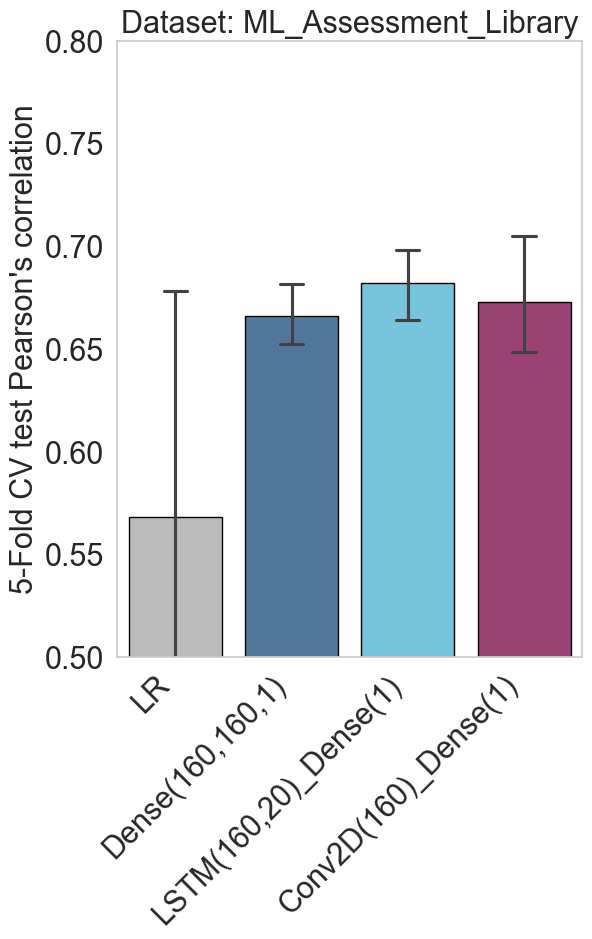

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Paul Tol's Notes color scheme
colors = ['#BBBBBB','#4477AA', '#66CCEE','#AA3377',]

# Function to darken a color (kept in case you want it later)
def darken_color(color, amount=0.1):
    c = mcolors.to_rgb(color)
    return mcolors.to_hex([max(0, c[i] - amount) for i in range(3)])

# ---- Convert data to long format ----
rows = []
for model_name in model_order:
    print(np.mean(pearson_results[model_name]))
    for corr in pearson_results[model_name]:
        rows.append({"Model": model_name, "Pearson": corr})

df = pd.DataFrame(rows)

# Color mapping (preserves your original ordering)
palette = {model: colors[i % len(colors)] for i, model in enumerate(model_order)}

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 8))

ax = sns.barplot(
    data=df,
    x="Model",
    y="Pearson",
    order=model_order,
    estimator=np.mean,
    errorbar=("ci", 95),   # use ci=95 if seaborn < 0.12
    capsize=0.2,
    edgecolor='black',
    palette=palette
)

# ---- Styling to match your original ----
ax.set_ylabel("5-Fold CV test Pearson's correlation", fontsize=22)
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=22)
ax.tick_params(axis='y', labelsize=22)
ax.set_ylim(0.50, 0.80)
ax.set_yticks(np.arange(0.5, 0.81, 0.05))

ax.grid(False)
plt.title("Dataset: ML_Assessment_Library", fontsize=22)
plt.show()